In [80]:
import os
import sys
sys.path.append(os.path.abspath(".."))
import pandas as pd
from etl.transform import transform
from etl.extractors import extract_data 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler

In [56]:
df=extract_data('../data/processed/cleansuperstoredata.csv')

2026-03-23 23:24:55,884 - etl.extractors -INFO - Loaded 9800 rows and 24 columns


In [57]:
df.isna().sum()

Row_ID              0
Order_ID            0
Order_Date       5841
Ship_Date        5985
Ship_Mode           0
Customer_ID         0
Customer_Name       0
Segment             0
Country             0
City                0
State               0
Postal_Code        11
Region              0
Product_ID          0
Category            0
Sub_Category        0
Product_Name        0
Sales               0
Order_Year       5841
Order_Month      5841
Order_Weekday    5841
Ship_Year        5985
Ship_Month       5985
Ship_Weekday     5985
dtype: int64

In [58]:
df.dtypes

Row_ID             int64
Order_ID          object
Order_Date        object
Ship_Date         object
Ship_Mode         object
Customer_ID       object
Customer_Name     object
Segment           object
Country           object
City              object
State             object
Postal_Code      float64
Region            object
Product_ID        object
Category          object
Sub_Category      object
Product_Name      object
Sales            float64
Order_Year       float64
Order_Month      float64
Order_Weekday     object
Ship_Year        float64
Ship_Month       float64
Ship_Weekday      object
dtype: object

In [59]:
df=transform(df)

2026-03-23 23:24:55,921 - etl.transform -INFO - Transformation started
2026-03-23 23:24:55,928 - etl.transform -INFO - Converted Order_Date to datetime
2026-03-23 23:24:55,932 - etl.transform -INFO - Converted Ship_Date to datetime
2026-03-23 23:24:55,939 - etl.transform -INFO - Date-based feature engineering completed
2026-03-23 23:24:56,017 - etl.transform -INFO - Cleaned categorical columns: ['Order_ID', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product_ID', 'Category', 'Sub_Category', 'Product_Name', 'Order_Weekday', 'Ship_Weekday']
2026-03-23 23:24:56,050 - etl.transform -INFO - Removed duplicates: 0 rows dropped
2026-03-23 23:24:56,051 - etl.transform -INFO - transformation completed


In [60]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Category,Sub_Category,Product_Name,Sales,Order_Year,Order_Month,Order_Weekday,Ship_Year,Ship_Month,Ship_Weekday
0,1,ca-2017-152156,2017-08-11,2017-11-11,second class,cg-12520,claire gute,consumer,united states,henderson,...,furniture,bookcases,bush somerset collection bookcase,261.9600,2017.0,8.0,friday,2017.0,11.0,saturday
1,2,ca-2017-152156,2017-08-11,2017-11-11,second class,cg-12520,claire gute,consumer,united states,henderson,...,furniture,chairs,"hon deluxe fabric upholstered stacking chairs,...",731.9400,2017.0,8.0,friday,2017.0,11.0,saturday
2,3,ca-2017-138688,2017-12-06,NaT,second class,dv-13045,darrin van huff,corporate,united states,los angeles,...,office supplies,labels,self-adhesive address labels for typewriters b...,14.6200,2017.0,12.0,wednesday,NaN,NaN,<NA>
3,4,us-2016-108966,2016-11-10,NaT,standard class,so-20335,sean o donnel,consumer,united states,fort lauderdale,...,furniture,tables,bretford cr4500 series slim rectangular table,957.5775,2016.0,11.0,thursday,NaN,NaN,<NA>
4,5,us-2016-108966,2016-11-10,NaT,standard class,so-20335,sean o donnel,consumer,united states,fort lauderdale,...,office supplies,storage,eldon fold n roll cart system,22.3680,2016.0,11.0,thursday,NaN,NaN,<NA>


In [61]:
df.dtypes

Row_ID                    int64
Order_ID         string[python]
Order_Date       datetime64[ns]
Ship_Date        datetime64[ns]
Ship_Mode        string[python]
Customer_ID      string[python]
Customer_Name    string[python]
Segment          string[python]
Country          string[python]
City             string[python]
State            string[python]
Postal_Code             float64
Region           string[python]
Product_ID       string[python]
Category         string[python]
Sub_Category     string[python]
Product_Name     string[python]
Sales                   float64
Order_Year              float64
Order_Month             float64
Order_Weekday    string[python]
Ship_Year               float64
Ship_Month              float64
Ship_Weekday     string[python]
dtype: object

In [62]:
df.isna().sum()

Row_ID              0
Order_ID            0
Order_Date       5841
Ship_Date        5985
Ship_Mode           0
Customer_ID         0
Customer_Name       0
Segment             0
Country             0
City                0
State               0
Postal_Code        11
Region              0
Product_ID          0
Category            0
Sub_Category        0
Product_Name        0
Sales               0
Order_Year       5841
Order_Month      5841
Order_Weekday    5841
Ship_Year        5985
Ship_Month       5985
Ship_Weekday     5985
dtype: int64

In [63]:
df.columns

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales', 'Order_Year', 'Order_Month', 'Order_Weekday',
       'Ship_Year', 'Ship_Month', 'Ship_Weekday'],
      dtype='object')

In [64]:
drop_columns=['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode','Customer_ID',
               'Customer_Name', 
       'Postal_Code', 'Product_Name','Ship_Year', 'Ship_Month', 'Ship_Weekday']
df_models=df.drop(columns=[col for col in drop_columns if col in df.columns],errors="ignore")

In [65]:
df_models.shape

(9800, 12)

In [66]:
X=df_models.drop(columns=['Sales'],errors="ignore")
y=df_models['Sales']

In [67]:
X

,Segment,Country,City,State,Region,Product_ID,Category,Sub_Category,Order_Year,Order_Month,Order_Weekday
0,consumer,united states,henderson,kentucky,south,fur-bo-10001798,furniture,bookcases,2017.0,8.0,friday
1,consumer,united states,henderson,kentucky,south,fur-ch-10000454,furniture,chairs,2017.0,8.0,friday
2,corporate,united states,los angeles,california,west,off-la-10000240,office supplies,labels,2017.0,12.0,wednesday
3,consumer,united states,fort lauderdale,florida,south,fur-ta-10000577,furniture,tables,2016.0,11.0,thursday
4,consumer,united states,fort lauderdale,florida,south,off-st-10000760,office supplies,storage,2016.0,11.0,thursday
...,...,...,...,...,...,...,...,...,...,...,...
9795,corporate,united states,chicago,illinois,central,off-bi-10003429,office supplies,binders,NaN,NaN,<NA>
9796,corporate,united states,toledo,ohio,east,off-ar-10001374,office supplies,art,2016.0,12.0,thursday
9797,corporate,united states,toledo,ohio,east,tec-ph-10004977,technology,phones,2016.0,12.0,thursday
9798,corporate,united states,toledo,ohio,east,tec-ph-10000912,technology,phones,2016.0,12.0,thursday


In [ ]:
X_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [69]:
num_cols=X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category", "string"]).columns.tolist()

In [72]:
#fill the missing values if there is 
for c in num_cols:
    med=X_train[c].median()
    X_train[c]=X_train[c].fillna(med)
    x_test[c]=x_test[c].fillna(med)

In [71]:
for c in cat_cols:
    mode_val = X_train[c].mode(dropna=True)
    fill_val = mode_val.iloc[0] if len(mode_val) > 0 else "unknown"
    X_train[c] = X_train[c].fillna(fill_val)
    x_test[c] = x_test[c].fillna(fill_val)

In [75]:
scaler = MinMaxScaler()
X_train_num = pd.DataFrame(
    scaler.fit_transform(X_train[num_cols]),
    columns=num_cols,
    index=X_train.index
)
X_test_num = pd.DataFrame(
    scaler.transform(x_test[num_cols]),
    columns=num_cols,
    index=x_test.index
)

In [76]:
#one hot encoding 
X_train_cat = pd.get_dummies(X_train[cat_cols], drop_first=True)
X_test_cat = pd.get_dummies(x_test[cat_cols], drop_first=True)


In [77]:
X_train_cat, X_test_cat = X_train_cat.align(X_test_cat, join="left", axis=1, fill_value=0)


In [ ]:
X_train_final = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_final = pd.concat([X_test_num, X_test_cat], axis=1)



In [81]:
model = LinearRegression()
model.fit(X_train_final, y_train)


LinearRegression()

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
preds = model.predict(X_test_final)
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 182.4831261632865
RMSE: 652.9036624970952
R2: 0.3622332153372567


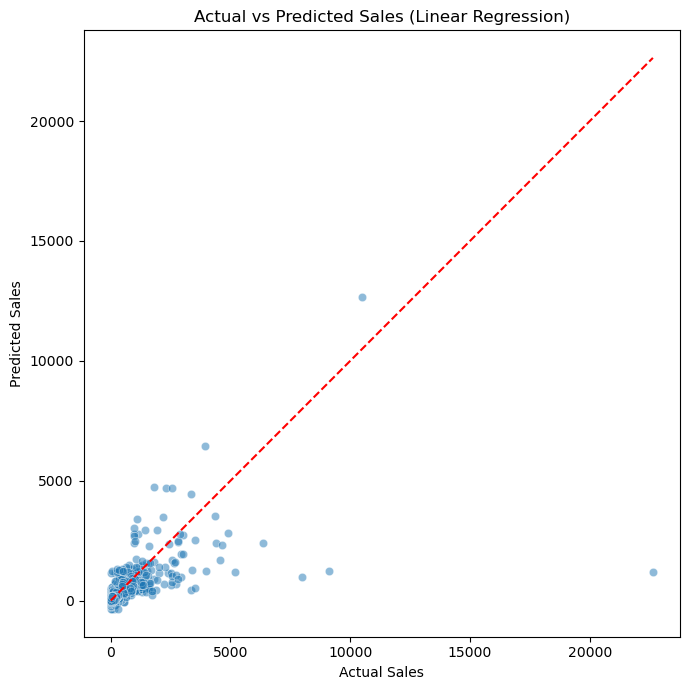

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=preds, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Linear Regression)")
plt.tight_layout()
plt.show()